In [1]:
import matplotlib.pyplot as plt
import numpy as np
import csv
import math

In [2]:
def prev_csv(data):
    list_data = []
    flag = 0
    for row in data:
        if flag == 0:
            flag += 1
        else:
            l = list(row)
            t = [float(i) for i in l]
            list_data.append(t)
    return list_data

Функция для "преврашения" файла с расширением csv в список

In [3]:
def data_normalized(list_dt, mean=None, std=None):
    if mean is None or std is None:
        mean = [0 for i in range(len(list_dt[0]) - 1)]
        for i in range(len(list_dt)):
            for j in range(len(list_dt[i]) - 1):
                mean[j] += list_dt[i][j]
        for i in range(len(mean)):
            mean[i] /= len(list_dt)
        std = [0 for i in range(len(mean))]
        for i in range(len(list_dt)):
            for j in range(len(list_dt[i]) - 1):
                std[j] += (list_dt[i][j] - mean[j]) ** 2
        for i in range(len(std)):
            std[i] /= len(list_dt)
            std[i] = std[i] ** 0.5
    else:
        mean = mean
        std = std
    new_list_dt = []
    for i in range(len(list_dt)):
        row_i = []
        for j in range(len(list_dt[i]) - 1):
            x_i_j = (list_dt[i][j] - mean[j]) / std[j]
            row_i.append(x_i_j)
        row_i.append(list_dt[i][-1])
        new_list_dt.append(row_i)
    return new_list_dt, mean, std

Функция, которая нормализует данные и любой диапазон меняет на диапазон от -1 до 1

In [4]:
def errors(data, v, b):
    mse = 0
    mn = 0
    for i in range(len(data)):
        pred = b
        for j in range(len(v)):
            pred += v[j] * data[i][j]
        err = data[i][-1] - pred
        mse += err * err
        mn += data[i][-1]
    mse /= len(data)
    rmse = mse ** 0.5

    mn /= len(data)
    ss_total = 0
    ss_res = 0
    for i in range(len(data)):
        pred = b
        for j in range(len(v)):
            pred += v[j] * data[i][j]
        ss_total += (mn - data[i][-1]) ** 2
        ss_res += (data[i][-1] - pred) ** 2

    r = 1 - ss_res / ss_total

    return mse, rmse, r

Функция возващающая три вида метрик: $MSE, RMSE, R^{2}$

In [5]:
def gradient(w, b, data, number_of_sings=20):
    grad = [0 for i in range(number_of_sings)]
    gradb = 0
    for i in range(len(data)):
        pred = b
        for j in range(number_of_sings):
            pred += w[j] * data[i][j]
        err = pred - data[i][-1]
        for j in range(number_of_sings):
            grad[j] += err * data[i][j] * 2
        gradb += err * 2
    for i in range(number_of_sings):
        grad[i] /= len(data)
    gradb /= len(data)
    return grad, gradb

Функция gradient считает градит от функции ошибки:
$$MSE=\frac{1}{n}\sum(y_i-y_{real})^2$$
Где $y_i$ это предсказанная цена, полученная перемножением текущих весов на параметры i-ой квартиры.

$y_{real}$ - реальная цена i-ой квартиры

$n$ - количество квартир

Стоит также отметить, что возвращается градиент от параметров и градиент от свободного члена отдельно

In [6]:
file = open("dataset_sample_3000.csv", 'r')
train_data = csv.reader(file)
train_list_data = prev_csv(train_data)
file.close()
train_list_data, mean, std = data_normalized(train_list_data)

file = open('dataset_sample_all.csv','r')
test_data = csv.reader(file)
test_list_data = prev_csv(test_data)
file.close()
test_list_data, mean, std = data_normalized(test_list_data, mean, std)

## Метод Momentum (метод моментов)

### Интуиция

Представьте, что вы катите мяч с горы. Мяч не просто движется в сторону наклона — он **накапливает скорость** или же приобретает некоторую инерцию. Если наклон долго направлен в одну сторону, мяч разгоняется. Если впереди подъём — мяч по инерции может его частично преодолеть, даже если градиент уже сменил направление.

**Momentum**- это метод реализующий эту идею с помощью обновления весов с дополнительной константой "скорость".

### Формулы

$$v_k = \beta \cdot v_{k-1} - \eta \cdot \nabla f(w_k)$$

$$w_{k+1} = w_k + v_k$$

Где:
- $v_k$ — **скорость** (накопленный градиент)
- $\beta$ — **коэффициент инерции** (насколько сильно влияет предыдущий спуск на следующий шаг)
- $\eta$ — **скорость обучения** (learning rate)
- $\nabla f(w_k)$ — **градиент** в текущей точке


Данная модификация обновления весов дает более быструю сходимость и позволяет преодолеть локальные минимумы, но также может пострадать точность при слишком больших $\beta$


In [63]:
def find_weight_momentum(data, tst_data, number_of_epochs = 50, rate_learning = 0.05, rate_inertion = 0.5):
    x = [0.0 for i in range(20)]
    v = [0.0 for i in range(20)]
    v_b = 0
    b = 0
    history = []
    for i in range(number_of_epochs):
        g, gradb = gradient(x, b, data)
        for j in range(len(x)):
            v[j] = v[j]*rate_inertion- (rate_learning*g[j])
            x[j]+=v[j]
        v_b = v_b*rate_inertion- (rate_learning*gradb)
        b+=v_b
        if i > 20:
            ms, _, r = errors(tst_data, x, b)
            history.append(r)
    return x, b, history

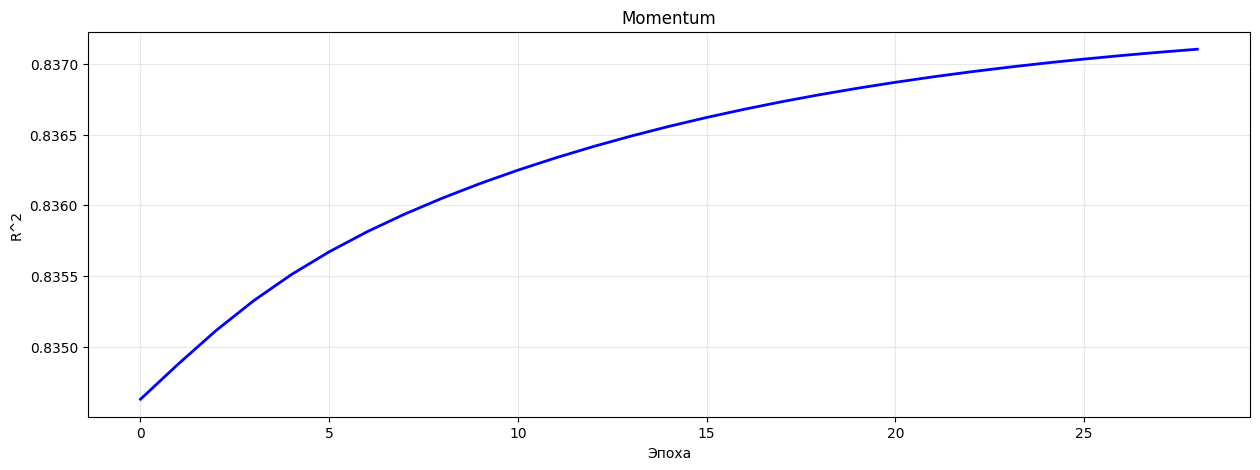

MSE: 0.04259455264378397
RMSE: 0.2063844777200649
R^2: 0.8371036493470138


In [64]:
x, b, history = find_weight_momentum(train_list_data, test_list_data)

mse_test, rmse_test, r_test = errors(test_list_data, x, b)
plt.figure(figsize=(15, 5))
plt.plot(history, color='blue', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('R^2')
plt.title('Momentum')
plt.grid(True, alpha=0.3)
plt.show()
print("MSE:", mse_test)
print("RMSE:", rmse_test)
print("R^2:", r_test)

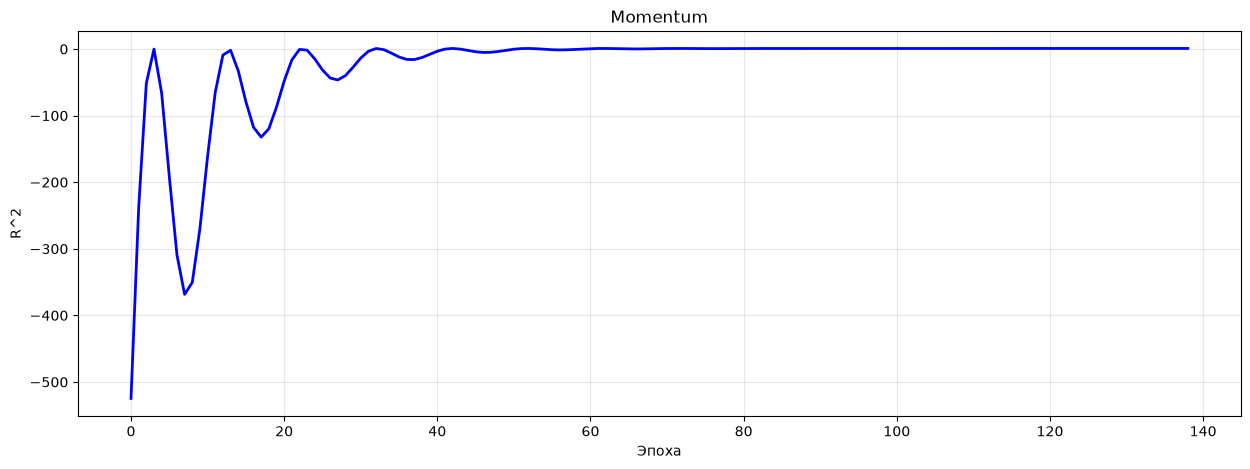
Этот график наглядно иллюстрирует что при высоком коэффиценте скорости очень быстро ~5 итераций достигается отимум и дальше происходят колебания(коэф. скорости=0.9) рассмотрим график не сначала а с 50 итерации

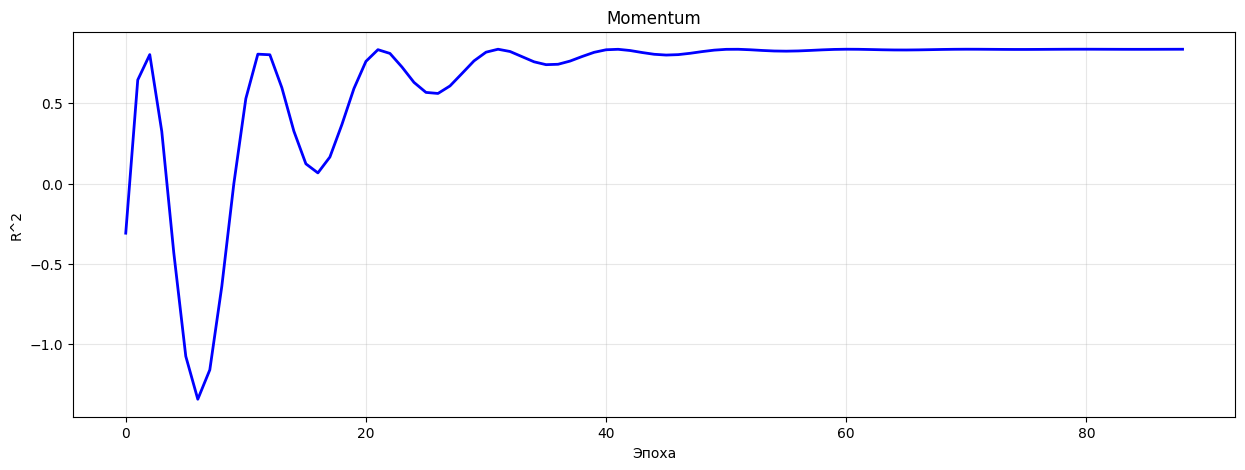
на графике видно что колебания постепенно затухают.
рассмотрим с 90 итерации чтоб понять когда сходится

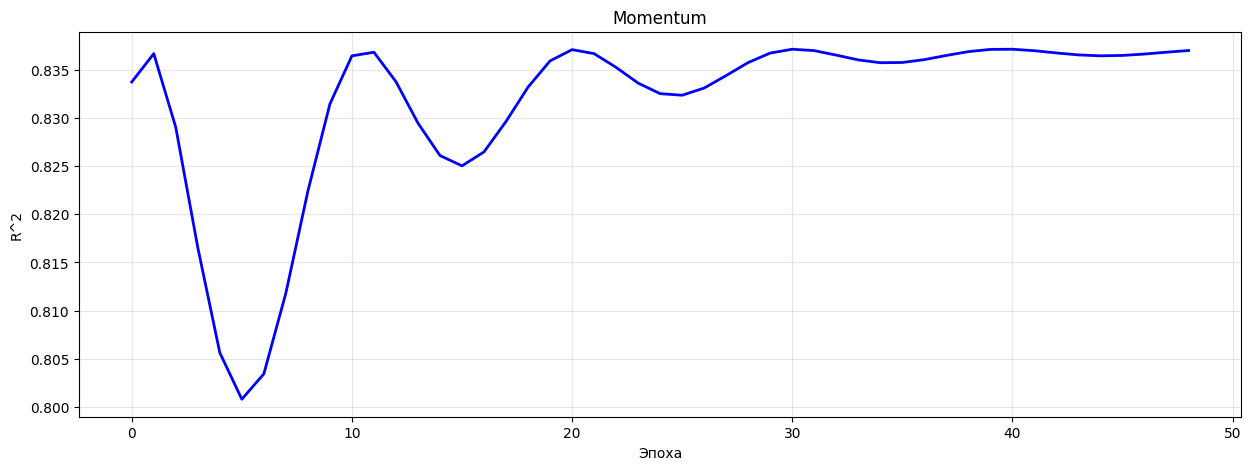 заметно что сходится примерно после 130 итерации

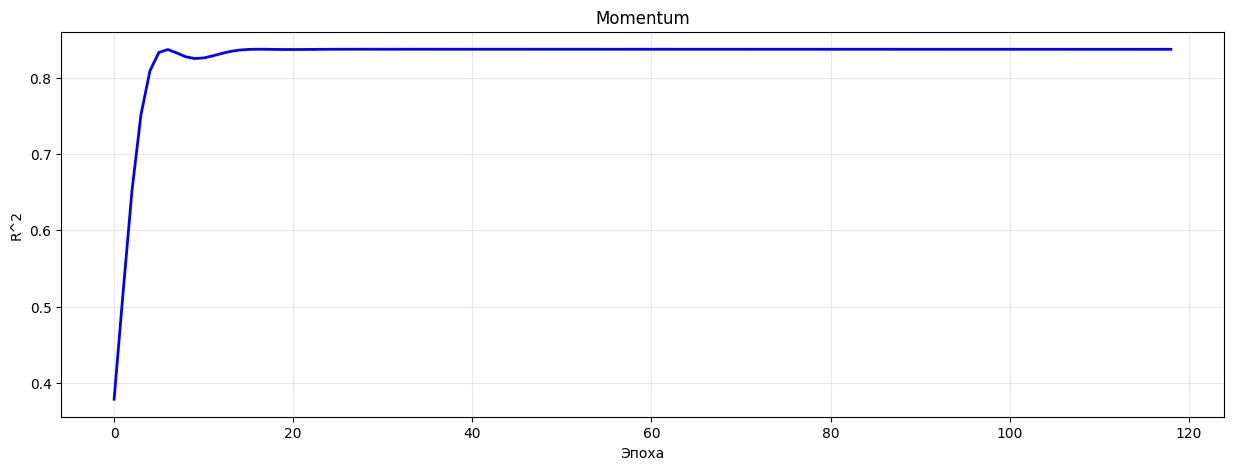
Заменив коофицунте скорости с 0.9 на 0.7 затухания происходят значительно быстрее. График сверху взят с 20 итерации наглядно это показывает.
То есть с коэф. скорости=0.7 сходится примерно за 50 итераций

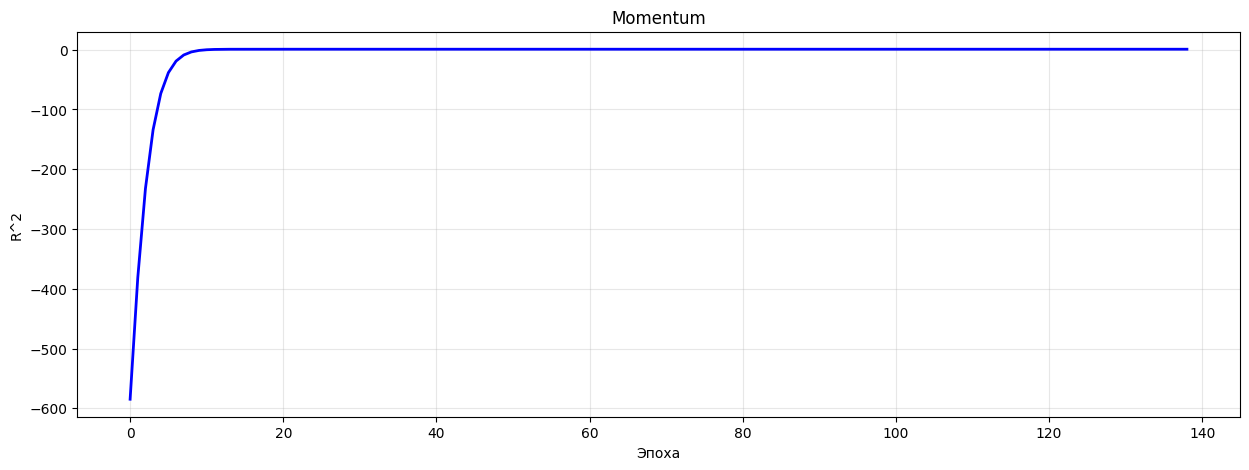
это график с коэф. скорости=0.5. можно заметить что колебаний почти нет. то есть это чуть ли не оптимальный параметр для данного алгоритма потому что береьт от него лучшее: скорость сходимости и игнорирует недостатки: колебание возле минимума. сходится примерно за 50 эпох.

Вывод: правильно подобранный параметр скорости может значительно ускорить работу алгоритма. Если взять слишком большой то метод будет долго колебаться если слишком маленький не будет сильно отличаться от обычного градиентного спуска.

## Ускоренный градиентный метод Нестерова (NAG)

### Интуиция

**Nesterov Accelerated Gradient (NAG)**- является модификацией предыдущего метода. Физической интерпретацией может служить бегун, который бежит с горки он набирает какую-то скорость что позволяет преодолеть локальные минимумы, но чуть-чуть притормаживает перед локальным минимум что позволяет быстрее достигнуть точки без долгих колебаний вокруг нее. Этот эффект дает новое обновление весов, где градиент считается от точки в которой он окажется в следующий момент, а не в текущей.


### Формулы

$$w_{look} = w_k + \beta \cdot v_{k-1}$$

$$v_k = \beta \cdot v_{k-1} - \eta \cdot \nabla f(w_{look})$$

$$w_{k+1} = w_k + v_k$$

Где:
- $w_{look}$ — **"заглядывающая вперёд"** точка (lookahead)
- $v_k$ — скорость (накопленный градиент)
- $\beta$ — коэффициент инерции
- $\eta$ — скорость обучения


In [61]:
def find_weight_Nesterov_momentum(data, tst_data, number_of_epochs = 50, rate_learning = 0.05, rate_inertion = 0.5):
    x = [0.0 for i in range(20)]
    v = [0.0 for i in range(20)]
    b = 0
    v_b = 0
    history = []
    for i in range(number_of_epochs):
        new_x = [x[j]+v[j]*rate_inertion for j in range(len(x))]
        g, gradb = gradient(new_x, b, data)
        for j in range(len(x)):
            v[j] = v[j]*rate_inertion- (rate_learning*g[j])
            x[j]+=v[j]
        v_b = v_b*rate_inertion- (rate_learning*gradb)
        b+=v_b
        if i > 20:
            ms, _, r = errors(tst_data, x, b)
            history.append(r)
    return x, b, history

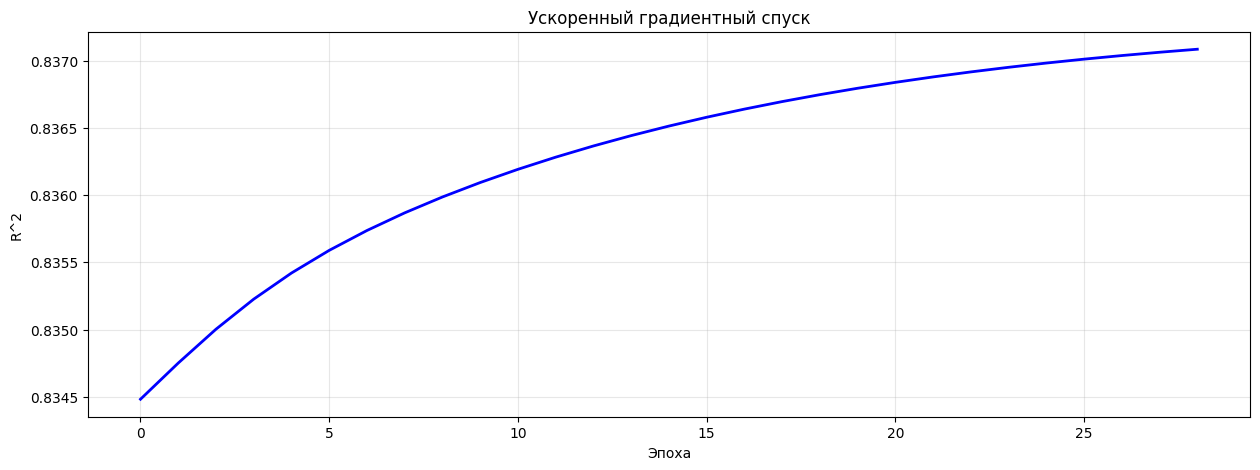

MSE: 0.042599476939911646
RMSE: 0.206396407284409
R^2: 0.8370848171297713


In [62]:
x, b, history = find_weight_Nesterov_momentum(train_list_data, test_list_data)

mse_test, rmse_test, r_test = errors(test_list_data, x, b)
plt.figure(figsize=(15, 5))
plt.plot(history, color='blue', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('R^2')
plt.title('Ускоренный градиентный спуск')
plt.grid(True, alpha=0.3)
plt.show()
print("MSE:", mse_test)
print("RMSE:", rmse_test)
print("R^2:", r_test)

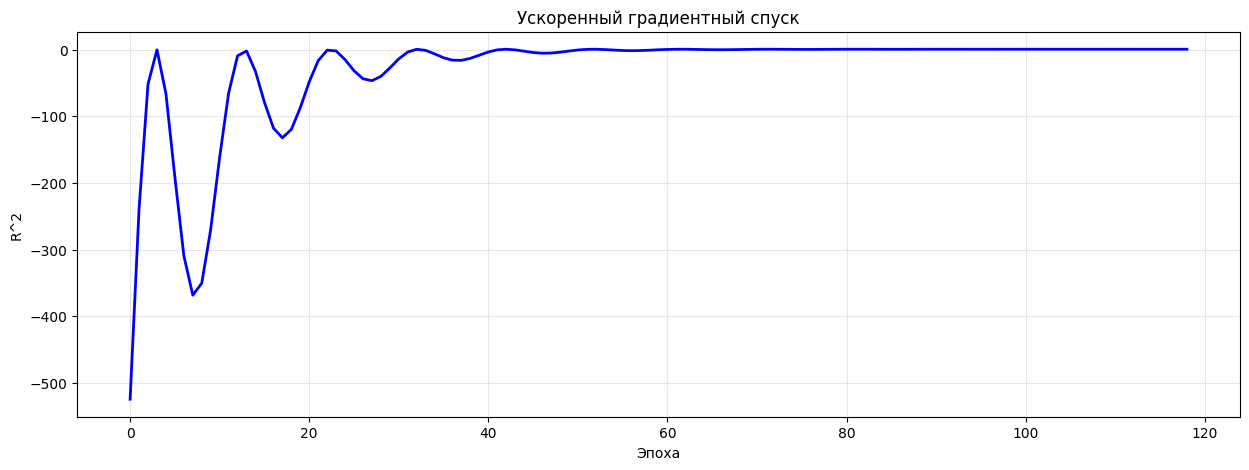Как и предыдущий алгорит проанализируем при большом коэффиценте(0.9) работу алгоритма

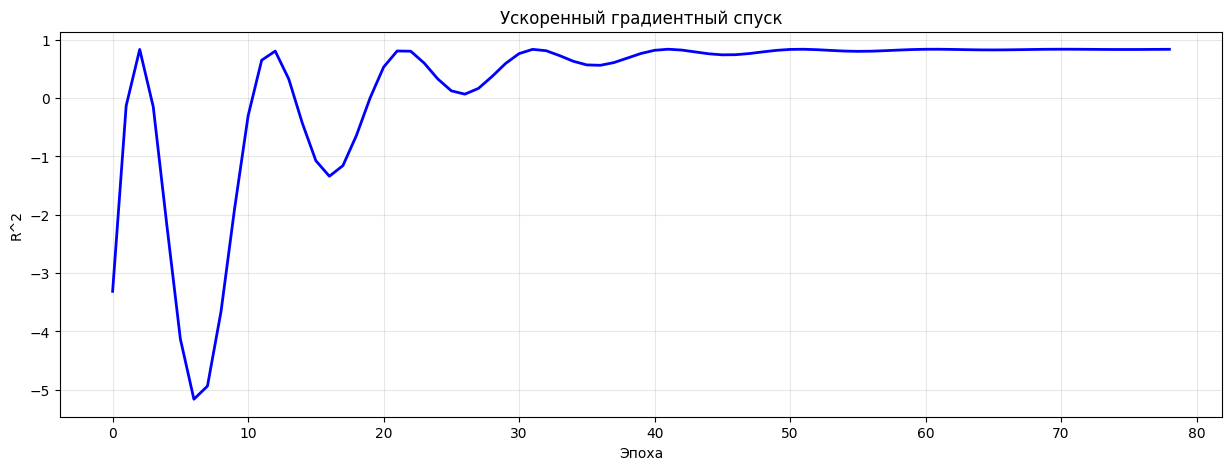 с 40 итерации

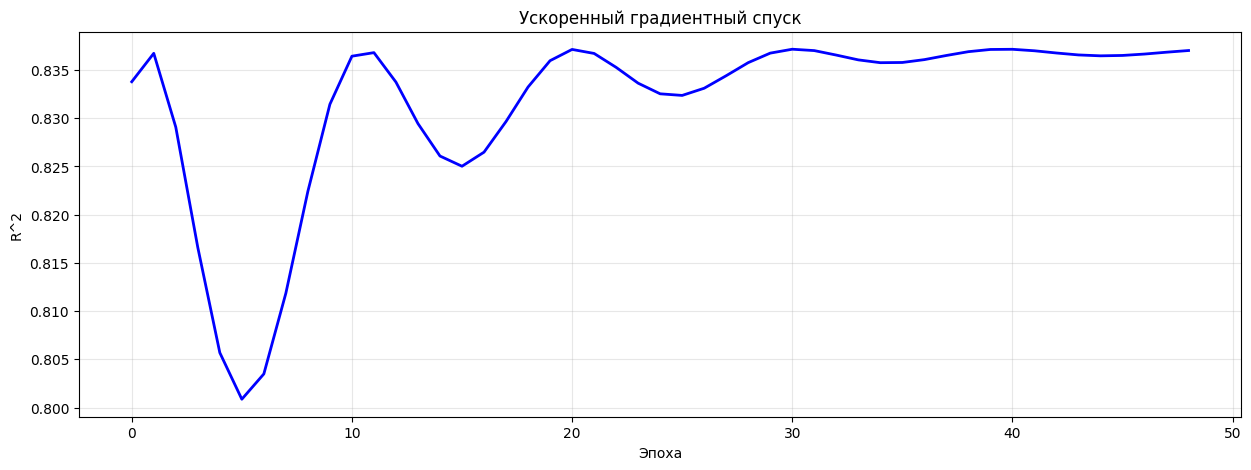 с 90 итерации. Можно заметить что колебание происходит дольше но с точностью до 3 знака после запятой алгоритм также сходится примерно со 130 итерации

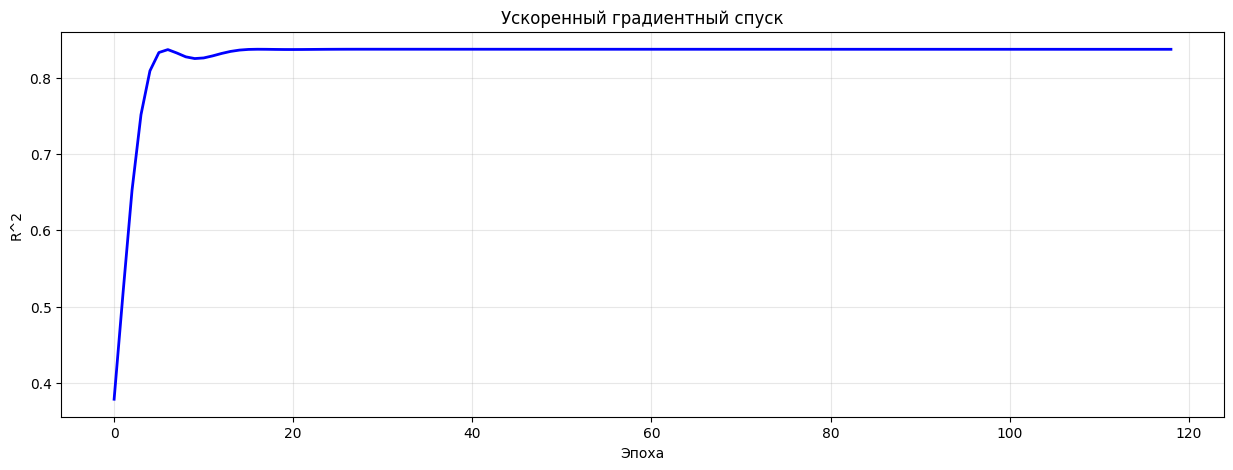 с 20 итерации.
Графики с предыдущим алгоритмом невероятно схожи возможно из-за того что только свободный член изначатьно отличается сильно от 0. сходится также примерно за 40 итераций

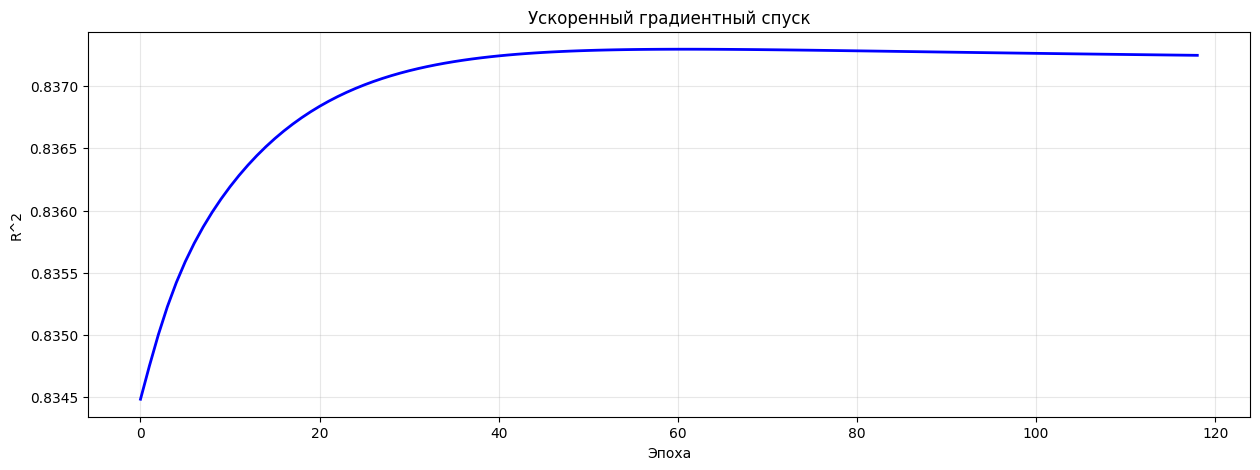
Это график с коэфицентом 0.5 и сходится он чуть быстрее чем моментум

Вывод:
В целом моментум и ускоренный градиентный спуск на больших кооэфицентах почти совпадают и второй алгоритм имеет некоторое преимущество при маленьких кооэфицентах. Отсюда следует что второй алгоритм лучше так как более терпим к недостаточно большим коэффицентам чем первый.

## Метод эллипсоидов

### Теория

Для того чтоб понять идею. Введем некоторое условие:
- каким-то образом мы знаем в какой области находятся оптимальные веса
- у нас есть метод определить в какой части этой области эти веса(точка) не находятся

Тогда можно ввести метод центров тяжести:

- Область в многомерном пространстве можно покрыть некоторым многогранником.
- У этого многогранника находим центр тяжести
- Центр тяжести это некоторый вектор у которого есть n координат, где n-кол-во весов
- Интерпретируем центр тяжести как веса и считаем градиент в этой точке
- Градиент также являющийся набор из n чисел указывает на ту часть многогранника в которой оптимальных весов нет
- Отсекаем ту часть на которую градиент указывает
- Получаем новый многогранник
- Повторяем данный алгоритм уже с новым многогранником до тех пор, пока центр многогранника не будет очень близок к оптимальным весам

Благодаря тому что мы отсекаем не менее 35 процентов (доказательство приведено в теореме Грюнбаума–Хаммера–Митягина) можно заметить что сходится этот метод довольно быстро, но очень тяжело реализовать поиск центра тяжести у какого-то многогранника.
Поэтому есть его модификация, которая упрощает эту задачу, но ухудшает скорость сходимости: **Метод эллипсоидов**

Идея заключается в следующем: вместо того чтоб работать с многогранником будем работать с эллипсоидом полностью покрывающем его.
А так как доказано, что любую часть эллипсоида можно покрыть меньшим эллипсоидом можем делать это на каждом шагу.
Тогда найти центр у эллипсоида значительно легче (так как его можно представить в виде матрицы) поиск центра тяжести значительно облегчается, но из-за того что мы на каждом этапе текущую часть заворачиваем в эллипсоид больший по объему чем сама часть (но меньший по объему чем изначальный эллипсоид) скорость сходимости ухудшается.

In [72]:
def elipsoid_method(data, tst_data, number_of_epochs = 1000, radius = 20):
    elipsoid = [[0.0 for i in range(21)] for i in range(21)]
    center = [0 for i in range(21)]
    center[20] = 10
    history = []
    for i in range(21):
        elipsoid[i][i] = radius**2
    for i in range(number_of_epochs):
        x = center[:20]
        b = center[20]
        g, gradb = gradient(x, b, data)
        g.append(gradb)
        start_h = g
        elipsoid1 = [0 for i in range(21)]
        for k in range(21):
            for j in range(21):
                elipsoid1[k] += elipsoid[k][j] * start_h[j]
        elipsoid2 = 0
        for k in range(21):
            elipsoid2 += elipsoid1[k] * start_h[k]
        h = [0 for i in range(21)]
        for k in range(21):
            h[k] = elipsoid1[k] / (elipsoid2 ** 0.5)

        for k in range(21):
            center[k] -= h[k] / 22

        for k in range(21):
            for j in range(21):
                elipsoid[k][j] -= (2 / 22) * h[k] * h[j]
                elipsoid[k][j] *= (441 / 440)
        if i >500 :
            ms, _, r = errors(tst_data, x, b)
            history.append(r)
    return center[:20], center[20], history


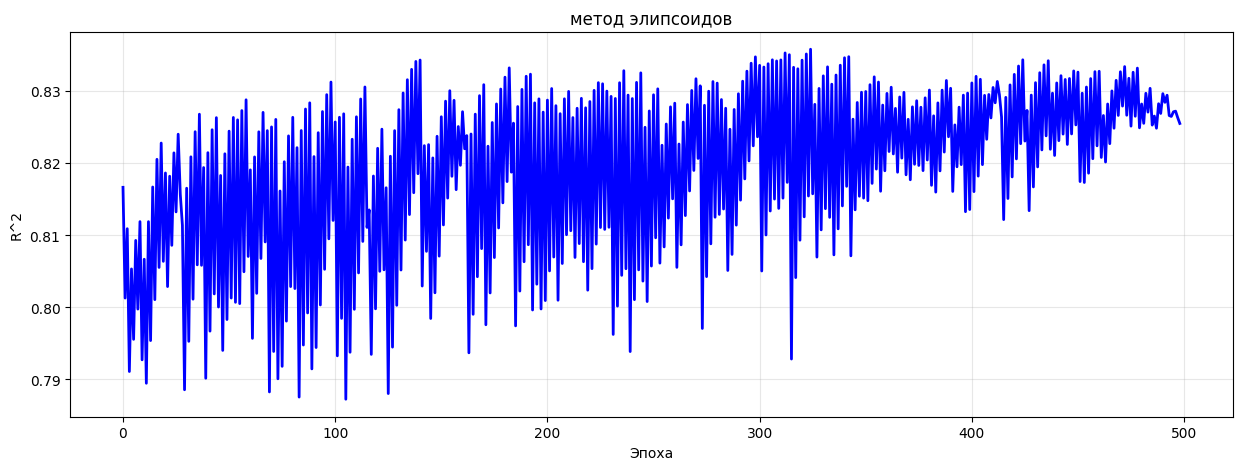

MSE: 0.04578108999321362
RMSE: 0.21396516069961863
R^2: 0.8249172247170258


In [73]:
x, b, history = elipsoid_method(train_list_data, test_list_data)

mse_test, rmse_test, r_test = errors(test_list_data, x, b)
plt.figure(figsize=(15, 5))
plt.plot(history, color='blue', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('R^2')
plt.title('метод элипсоидов')
plt.grid(True, alpha=0.3)
plt.show()
print("MSE:", mse_test)
print("RMSE:", rmse_test)
print("R^2:", r_test)

Заметим что если подобрать начальные веса близкие к оптимальным и уменьшить радиус то сходимость значительно улучшится в 2-3 раза. как график выше. Но тогда возникает закономерный вопрос: смысл этого алгоритма если мы знаем уже достаточно близкие данные, то зачем нам в данной задаче использовать метод эллипсоидов вместо бычного градиентного спуска? Поэтому анализировать данные я буду в тот случае когда радиус равен 20. Естественно это не говорит что метод эллипсоидов плох. его можно применить в очень сложных функциях и я думаю что там себя он покажет значительно лучше других реализованных методов в этой работе.

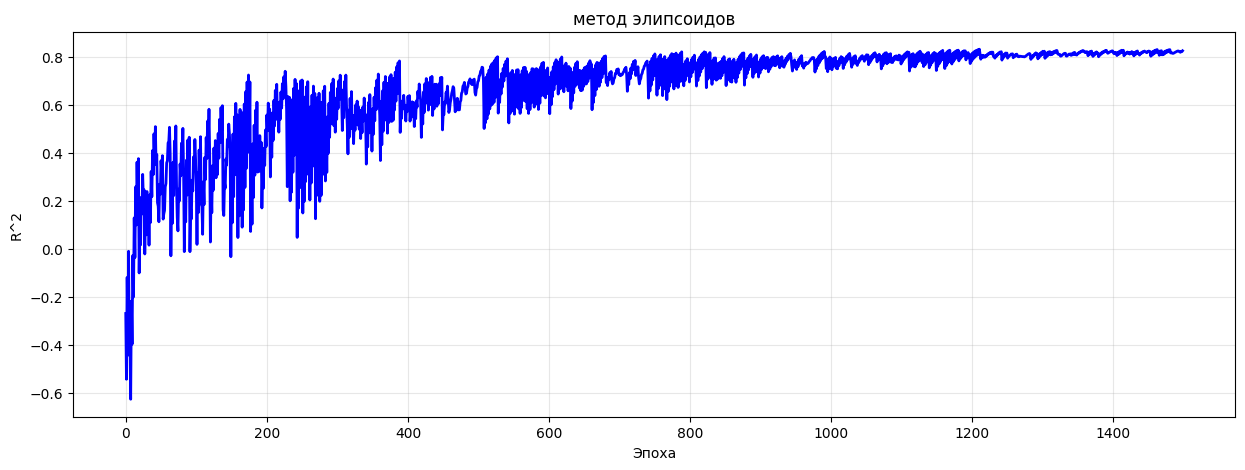
можно заметить что сходится ошибка не плавно, но это в сиу природы метода.

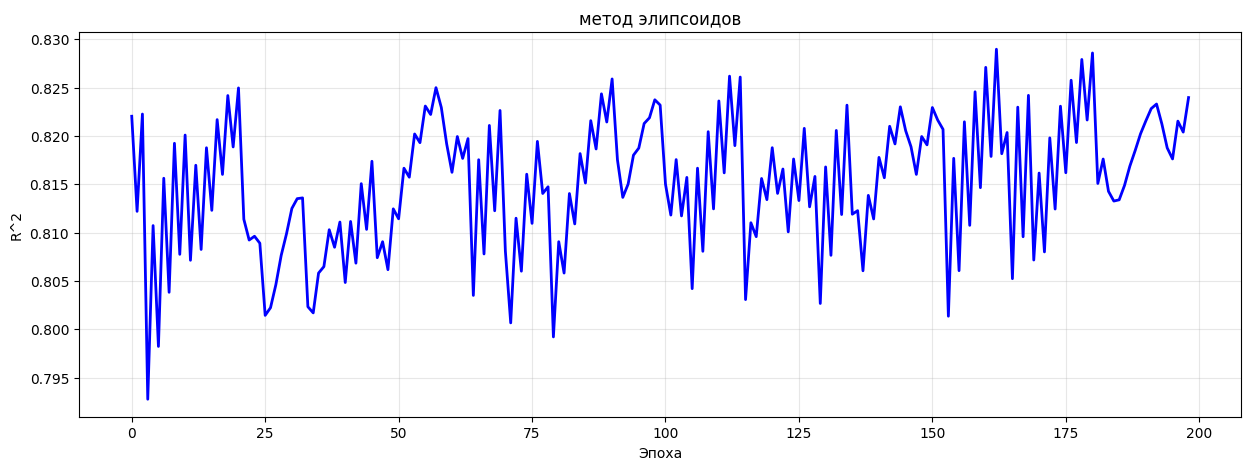
это итерации с 1300-1500. Даже если значения очень "скачущие" метод постепенно сходится, правда делает это очень медленно.

# Итоги


## Анализ влияния гиперпараметров и характера сходимости

На основе кривых обучения можно сделать следующие выводы:

- **Специфика Momentum:** Метод крайне чувствителен к выбору $\beta$. При $\beta = 0.09$ инерция накапливается очень быстро, и из-за этого возникают долгие колебания. Для эффективной работы Momentum требуется $\beta \approx 0.5-0.7$, что позволяет накапливать скорость на пологих участках и сглаживать осцилляции в оврагах.

- **Специфика Nesterov:** Благодаря "взгляду вперёд" метод менее чувствителен к выбору $\beta$. Поэтому при маленьких $\beta$ ведет себя чуть лучше чем моментум в остальном они совпадают

- **Специфика метода эллипсоидов:** Характер сходимости принципиально отличается от градиентных методов — наблюдаются скачки $R^2$ от итерации к итерации.. Качество гарантированно улучшается лишь при достаточном сжатии области. Критичен выбор начального радиуса: слишком маленький не накроет минимум, слишком большой требует больше итераций.


## Сравнение вычислительной сложности

| Метод | Сложность итерации | Эпох до сходимости | Время (сек) |
|-------|-------------------|---------------------|-------------|
| Momentum | $O(nd)$ | ~50 | 3 |
| **Nesterov** | $O(nd)$ | **~45** | **3** |
| Эллипсоиды | $O(n^2)$ | ~1500 | 40 |


# Заключение

Эксперимент наглядно продемонстрировал преимущество ускоренных градиентных методов над классическими подходами.

Ключевые результаты:
1. **Nesterov — победитель:** стабильность
2. **Momentum требует тщательного подбора $\beta$:** при $\beta = 0.05$ вырождается в медленный SGD, рекомендуется $\beta = 0.7$
3. **Метод эллипсоидов — нишевый инструмент:** интересен теоретически, но проигрывает градиентным методам на практике из-за вычислительной сложности $O(n^2)$
4. **Все методы достигли близкого качества** ($R^2 \approx 0.8-0.84$), что подтверждает устойчивость линейной модели для задачи прогнозирования стоимости квартир
